# ARIMA (AutoRegressive Integrated Moving Average)

ARIMA is a statistical method for modelling and forecasting time series data. AutoRegressive (AR) models the relationship between the current value and past values in the time series. In simple words, it looks at how past observations influence future ones. The Integrated (I) component involves differencing the time series data to make it stationary. Stationarity is a critical assumption for ARIMA models. The moving Average (MA) part models the relationship between the current value and past forecast errors.

# SARIMA (Seasonal AutoRegressive Integrated Moving Average)

SARIMA extends ARIMA by including seasonal components to account for seasonality in the data. Seasonal patterns are often observed in many time series data, such as quarterly sales or monthly temperature data.

SARIMA models are well-suited for data that exhibits both non-seasonal and seasonal patterns.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/social-media-reach-forecasting-case-study/Instagram-Reach.csv


* Start with data collection and preprocessing.

* Analyze the data to determine whether it exhibits trends and seasonality.
 
* If trends are present, apply differencing to make the data stationary.

* Identify appropriate values for AR, I, and MA orders based on autocorrelation and partial autocorrelation plots.

* For SARIMA, also determine seasonal orders.

* Estimate the model parameters using historical data.

* Finally, use the model for forecasting future data points.


In [2]:
# Python libraries required for the task of Time Series Forecasting using ARIMA.
# Import necessary libraries 
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pio.templates.default = "plotly_white"

In [3]:
# Load and read the data
data = pd.read_csv('/kaggle/input/social-media-reach-forecasting-case-study/Instagram-Reach.csv')

In [4]:
data.head()

,Date,Instagram reach
0,2022-04-01T00:00:00,7620
1,2022-04-02T00:00:00,12859
2,2022-04-03T00:00:00,16008
3,2022-04-04T00:00:00,24349
4,2022-04-05T00:00:00,20532


Extract date values from the date column

In [5]:
# Extracting only date values from the date cloumn
data["Date"] = pd.to_datetime(data["Date"])


# Extract only the date part from the "Date" column
data["Date"] = data["Date"].dt.date

In [6]:
data.head()

,Date,Instagram reach
0,2022-04-01,7620
1,2022-04-02,12859
2,2022-04-03,16008
3,2022-04-04,24349
4,2022-04-05,20532


In [7]:
# visualizing the trend of the data

fig = go.Figure()
fig.add_trace(go.Scatter(x=data['Date'],
                         y=data['Instagram reach'],
                         mode='lines', name='Instagram reach'))


fig.update_layout(title='Instagram Reach Trend', xaxis_title='Date', yaxis_title='Instagram Reach')


fig.show()

this data is not stationary, and it’s not appropriate to use the ARIMA model on such data. On such data, we can use the SARIMA model

let’s continue with the implementation of ARIMA on this dataset only:

In [8]:
# Resetting the index
time_series = data.set_index('Date')['Instagram reach']

# Differencing
differenced_series = time_series.diff().dropna()

# Assign the differenced series to a new variable 
differenced_series_data = differenced_series.values

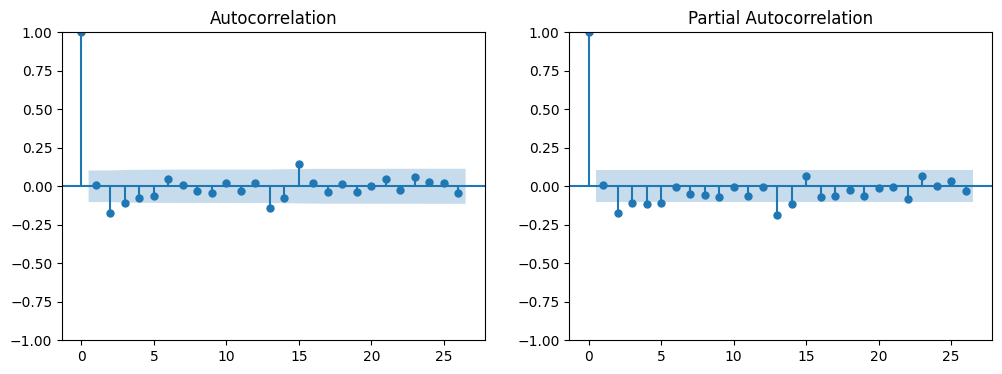

In [9]:
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series_data, ax=axes[0])
plot_pacf(differenced_series_data, ax=axes[1])
plt.show()

In the above graphs, the ACF plot cuts off at lag 1, indicating q=1. The PACF plot also cuts off at lag 1, indicating p=1.

here are the definitions and equations for the parameters p, d, and q in an ARIMA (Autoregressive Integrated Moving Average) model:

p: The number of autoregressive (AR) terms
- Represents the number of lags of the stationarized series in the model
- Equation: y_t = c + φ_1*y_(t-1) + φ_2*y_(t-2) + ... + φ_p*y_(t-p) + ε_t

d: The number of times the series needs to be differenced to achieve stationarity
- Represents the order of differencing
- If d = 0, the series is already stationary
- If d = 1, the series needs to be differenced once to achieve stationarity
- If d = 2, the series needs to be differenced twice to achieve stationarity

q: The number of lagged forecast error terms (moving average terms)
- Represents the number of lags of the forecast errors in the model
- Equation: y_t = c + ε_t + θ_1*ε_(t-1) + θ_2*ε_(t-2) + ... + θ_q*ε_(t-q)

The combined ARIMA(p,d,q) model equation is:

y'_t = c + φ_1*y'_(t-1) + ... + φ_p*y'_(t-p) + θ_1*ε_(t-1) + ... + θ_q*ε_(t-q) + ε_t

Where:
- y'_t is the differenced series (differenced d times)
- c is a constant
- φ_i are the autoregressive coefficients
- θ_j are the moving average coefficients
- ε_t is the error term at time t

The values of p, d, and q need to be determined based on the characteristics of the time series data, often by analyzing the ACF and PACF plots.

In [10]:
# Implementing ARIMA model to forecast time series
p, d, q = 1, 1, 1 # d = 1 becouse the data is non-stationary
model = ARIMA(time_series, order=(p, d, q))
results = model.fit()

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



In [11]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        Instagram reach   No. Observations:                  365
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4026.336
Date:                Fri, 12 Apr 2024   AIC                           8058.672
Time:                        05:23:11   BIC                           8070.364
Sample:                    04-01-2022   HQIC                          8063.319
                         - 03-31-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7791      0.046     17.084      0.000       0.690       0.869
ma.L1         -0.9607      0.022    -44.607      0.000      -1.003      -0.918
sigma2      2.559e+08   2.81e-11   9.11e+18      0.000    2.56e+08    2.56e+08
===================================================================================
Ljung-Box (L1) (Q):                   3.81   Jarque-Bera (JB):               297.33
Prob(Q):                              0.05   Prob(JB):                         0.00
Heteroskedasticity (H):               0.83   Skew:                             0.18
Prob(H) (two-sided):                  0.30   Kurtosis:                         7.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 4.05e+34. Standard errors may be unstable.
"""

Let us see the predicted values for the next 100 days:

In [12]:
# Predict future values
future_steps = 100
predictions = results.predict(len(time_series), len(time_series) + future_steps - 1)

In [13]:
predictions 

2023-04-01    23434.362332
2023-04-02    24541.004432
2023-04-03    25403.218747
2023-04-04    26074.992871
2023-04-05    26598.389971
                  ...     
2023-07-05    28444.663196
2023-07-06    28444.663196
2023-07-07    28444.663196
2023-07-08    28444.663196
2023-07-09    28444.663196
Freq: D, Name: predicted_mean, Length: 100, dtype: float64

let's analyze the residuals of the ARIMA model to assess its performance and the reliability of the forecasts

In [14]:
# Obtain residues from the fitted ARIMA model
residuals = results.resid

Now, we can perform various checks and visualizations on the residuals to evaluate the model's assumptions and forecasting accuracy.

# Residual Plot: 

We can plot the residuals over time to check for any patterns or trends that may suggest a violation of the model assumptions.

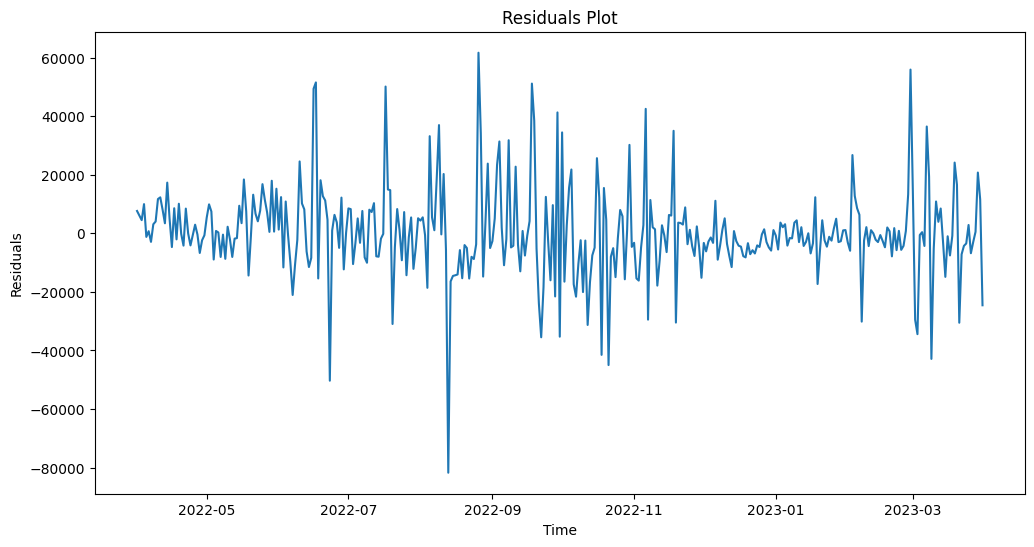

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(residuals)
plt.title('Residuals Plot')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.show()

If there are evident patterns or trends, it may indicate that the model is not adequately capturing the underlying data structure.

# Residual Distribution: 

We can check the distribution of the residuals to see if they follow a normal distribution, as assumed by the ARIMA model.

In [16]:
# Import library 
import statsmodels.api as sm

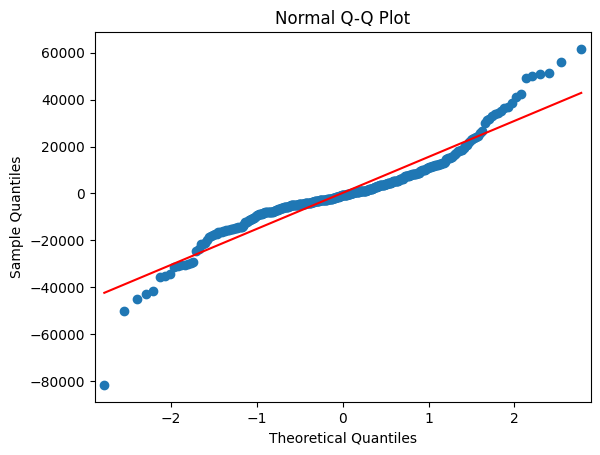

In [17]:
sm.qqplot(residuals, line='s')
plt.title('Normal Q-Q Plot')
plt.show()

The residuals should be randomly distributed around zero without any clear patterns or trends. 

# If there are evident patterns or trends, 

it may indicate that the model is not adequately capturing the underlying data structure.

# Residual Autocorrelation: 

We can check for autocorrelation in the residuals using the Ljung-Box test. Autocorrelated residuals may indicate that the model is not capturing all the relevant information in the data.

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox

The Ljung-Box test should have p-values greater than the significance level (e.g., 0.05) for all lags, indicating no significant autocorrelation in the residuals.

In [19]:
lb_test = acorr_ljungbox(residuals, lags=[1, 5, 10])
lb_test

,lb_stat,lb_pvalue
1,3.857263,0.049531
5,7.897075,0.162000
10,10.618282,0.388020


# Additionally, 
examine the confidence intervals of the forecasts to get an idea of the uncertainty associated with the predicted values. Here's an example of how to obtain and plot the confidence intervals: 



In [20]:
# Get the confidance intervals of the forecast 
conf_int = results.get_prediction(start=len(time_series), end=len(time_series)+future_steps-1).conf_int()

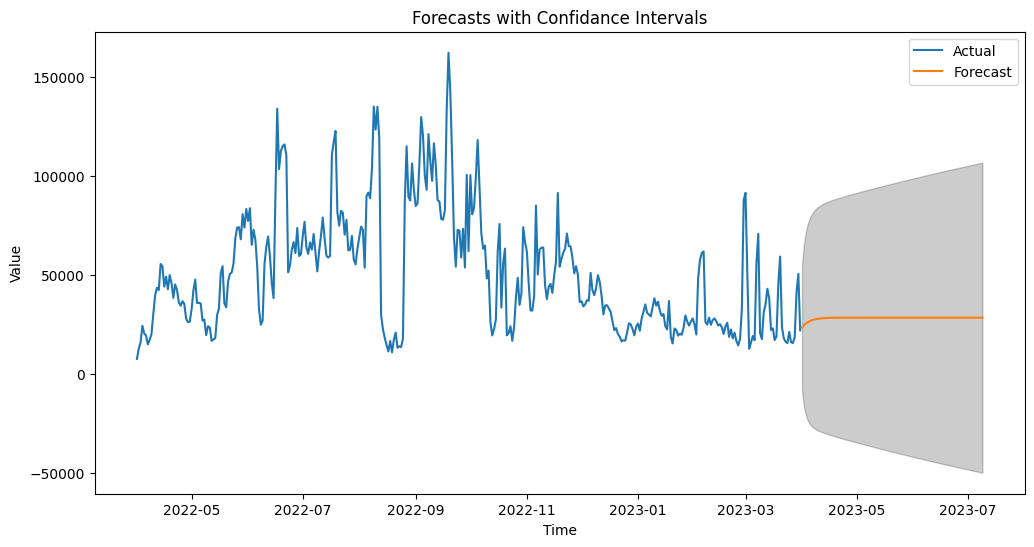

In [21]:
# Plot the forecast with confidance intervals
plt.figure(figsize=(12, 6))
plt.plot(time_series, label='Actual')
plt.plot(predictions, label='Forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='k', alpha=0.2)
plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Forecasts with Confidance Intervals')
plt.show()

# To implement the SARIMA model, 

follow the same process we followed to implement the ARIMA model. Below are the changes you need to make in your implementation of ARIMA to implement the SARIMA model.

In [22]:
# Import SARIMAX class
from statsmodels.tsa.statespace.sarimax import SARIMAX

implement SARIMA, change your model from ARIMA to SARIMA and add seasonality parameters as shown in the code below:

In [23]:
p, d, q, s = 1, 1, 1, 12

model = SARIMAX(time_series, order=(p, d, q), seasonal_order=(p, d, q, s))
results = model.fit()

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/conda/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.08457D+01    |proj g|=  6.06373D-02

At iterate    5    f=  1.08237D+01    |proj g|=  7.45189D-03

At iterate   10    f=  1.08171D+01    |proj g|=  1.35539D-02

At iterate   15    f=  1.08075D+01    |proj g|=  8.89149D-03

At iterate   20    f=  1.08070D+01    |proj g|=  9.41533D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     23     30      1     0     0   2.130D-05   1.081D+01
  F =   10.806974874372525     

CONVERG

In [24]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                    Instagram reach   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3944.546
Date:                            Fri, 12 Apr 2024   AIC                           7899.092
Time:                                    05:23:18   BIC                           7918.410
Sample:                                04-01-2022   HQIC                          7906.779
                                     - 03-31-2023                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7847      0.086      9.116      0.000       0.616       0.953
ma.L1         -0.9596      0.045    -21.472      0.000      -1.047      -0.872
ar.S.L12      -0.0685      0.117     -0.587      0.557      -0.297       0.160
ma.S.L12      -0.8396      0.073    -11.537      0.000      -0.982      -0.697
sigma2      5.067e+08   3.24e-11   1.57e+19      0.000    5.07e+08    5.07e+08
===================================================================================
Ljung-Box (L1) (Q):                   3.77   Jarque-Bera (JB):               237.09
Prob(Q):                              0.05   Prob(JB):                         0.00
Heteroskedasticity (H):               0.77   Skew:                             0.34
Prob(H) (two-sided):                  0.17   Kurtosis:                         6.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.26e+35. Standard errors may be unstable.
"""

Based on the provided SARIMAX model output, here are my observations and analysis:

1. **Model Order**: The model is specified as SARIMAX(1, 1, 1)x(1, 1, 1, 12), which means:
   - Regular ARIMA: (1, 1, 1) - AR order = 1, Differencing order = 1, MA order = 1
   - Seasonal ARIMA: (1, 1, 1, 12) - Seasonal AR order = 1, Seasonal Differencing order = 1, Seasonal MA order = 1, Seasonality period = 12 (likely monthly data)

2. **Coefficients and Significance**:
   - The regular AR coefficient (ar.L1) is 0.7847 and is statistically significant (p-value < 0.05).
   - The regular MA coefficient (ma.L1) is -0.9596 and is statistically significant (p-value < 0.05).
   - The seasonal AR coefficient (ar.S.L12) is -0.0685 and is not statistically significant (p-value > 0.05).
   - The seasonal MA coefficient (ma.S.L12) is -0.8396 and is statistically significant (p-value < 0.05).

3. **Residual Analysis**:
   - The Ljung-Box Q-statistic for the first lag is 3.77, with a p-value of 0.05, indicating no significant autocorrelation in the residuals at the 5% significance level.
   - The Jarque-Bera statistic is 237.09, with a p-value of 0.00, suggesting that the residuals are not normally distributed.
   - The heteroskedasticity test (H) has a p-value of 0.17, indicating no significant heteroskedasticity in the residuals.

4. **Model Fit**:
   - The log-likelihood value is -3944.546, which is used for model comparison and selection.
   - The AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) are also provided, which can be used for model selection, with lower values indicating better fit.

5. **Residual Distribution**:
   - The skewness value of 0.34 indicates that the residuals are slightly positively skewed.
   - The kurtosis value of 6.96 suggests that the residuals have heavier tails than a normal distribution (kurtosis of 3).

Overall, the SARIMAX model seems to capture the regular (non-seasonal) and seasonal patterns in the data reasonably well, as indicated by the significant regular and seasonal MA coefficients. However, the violation of the normality assumption for the residuals and the slightly heavy-tailed distribution may be areas of concern.

# The value of s in SARIMA represents 

the seasonal period or the number of time steps in each seasonal cycle. In time series data, seasonality often occurs at regular intervals. For example, in monthly data, the seasonality repeats every 12 months, while in daily data, it may repeat every 7 days (weekly seasonality) or every 30 days (monthly seasonality).

In the provided SARIMA example, the value of s is set to 12, indicating that the time series data exhibits seasonality with a repeating pattern every 12-time steps. It typically corresponds to a seasonal cycle of 12 months, suggesting that the data has yearly seasonality.